# 02 Price analysis

This notebook investigates Eurostat household electricity prices for the selected countries.

The focus is on household prices because this is the public-facing concern: what people actually pay.

*Consumer prices include taxes, levies, network costs and retail margins, so they are not the same as generation costs. This is descriptive only

In [9]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

In [12]:
# Jupyter is currently open inside the notebooks folder.
# This block makes the project root point one level up if needed.

from pathlib import Path

CURRENT_FOLDER = Path.cwd()

if CURRENT_FOLDER.name == "notebooks":
    PROJECT_ROOT = CURRENT_FOLDER.parent
else:
    PROJECT_ROOT = CURRENT_FOLDER

HOUSEHOLD_PRICE_PATH = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "eurostat"
    / "eurostat_nrg_pc_204_household_prices.csv"
)

print("Current folder:", CURRENT_FOLDER)
print("Project root:", PROJECT_ROOT)
print("Household price file exists:", HOUSEHOLD_PRICE_PATH.exists())
print("Household price path:", HOUSEHOLD_PRICE_PATH)

Current folder: C:\Users\Tristan\Projects\nuclear-prices-carbon-europe\notebooks
Project root: C:\Users\Tristan\Projects\nuclear-prices-carbon-europe
Household price file exists: True
Household price path: C:\Users\Tristan\Projects\nuclear-prices-carbon-europe\data\raw\eurostat\eurostat_nrg_pc_204_household_prices.csv


In [13]:
# Load the Eurostat household price CSV into a dataframe.
household_raw = pd.read_csv(HOUSEHOLD_PRICE_PATH)


print("Rows:", len(household_raw))
print("Columns:", len(household_raw.columns))

print("\nColumn names:")
print(list(household_raw.columns))


household_raw.head()

Rows: 213
Columns: 13

Column names:
['DATAFLOW', 'LAST UPDATE', 'freq', 'siec', 'nrg_cons', 'unit', 'tax', 'currency', 'geo', 'TIME_PERIOD', 'OBS_VALUE', 'OBS_FLAG', 'CONF_STATUS']


,DATAFLOW,LAST UPDATE,freq,siec,nrg_cons,unit,tax,currency,geo,TIME_PERIOD,OBS_VALUE,OBS_FLAG,CONF_STATUS
0,ESTAT:NRG_PC_204(1.0),28/04/26 23:00:00,"Half-yearly, semesterly",Electricity,Consumption from 2 500 kWh to 4 999 kWh - band DC,Kilowatt-hour,All taxes and levies included,Euro,Austria,2007-S2,0.1740,NaN,NaN
1,ESTAT:NRG_PC_204(1.0),28/04/26 23:00:00,"Half-yearly, semesterly",Electricity,Consumption from 2 500 kWh to 4 999 kWh - band DC,Kilowatt-hour,All taxes and levies included,Euro,Austria,2008-S1,0.1779,NaN,NaN
2,ESTAT:NRG_PC_204(1.0),28/04/26 23:00:00,"Half-yearly, semesterly",Electricity,Consumption from 2 500 kWh to 4 999 kWh - band DC,Kilowatt-hour,All taxes and levies included,Euro,Austria,2008-S2,0.1772,NaN,NaN
3,ESTAT:NRG_PC_204(1.0),28/04/26 23:00:00,"Half-yearly, semesterly",Electricity,Consumption from 2 500 kWh to 4 999 kWh - band DC,Kilowatt-hour,All taxes and levies included,Euro,Austria,2009-S1,0.1909,NaN,NaN
4,ESTAT:NRG_PC_204(1.0),28/04/26 23:00:00,"Half-yearly, semesterly",Electricity,Consumption from 2 500 kWh to 4 999 kWh - band DC,Kilowatt-hour,All taxes and levies included,Euro,Austria,2009-S2,0.1909,NaN,NaN


In [14]:
columns_to_check = [
    "siec",        # Energy product, should be Electricity
    "nrg_cons",   # Consumption band, e.g. band DC
    "tax",        # Tax/levy treatment
    "currency",   # Currency, e.g. Euro
    "unit",       # Unit, e.g. Kilowatt-hour
    "geo",        # Country
]

for col in columns_to_check:
    print(f"\n--- {col} ---")
    print(household_raw[col].dropna().unique())


--- siec ---
['Electricity']

--- nrg_cons ---
['Consumption from 2 500 kWh to 4 999 kWh - band DC']

--- tax ---
['All taxes and levies included']

--- currency ---
['Euro']

--- unit ---
['Kilowatt-hour']

--- geo ---
['Austria' 'Czechia' 'Germany' 'France' 'Slovakia' 'United Kingdom']


In [15]:
COUNTRIES = [
    "Austria",
    "Czechia",
    "France",
    "Germany",
    "Slovakia",
    "United Kingdom",
]

# Apply a strict like-for-like filter:
# - electricity only
# - household band DC, 2,500 to 4,999 kWh
# - all taxes and levies included
# - Euro
# - per kWh
# - selected countries only
household = household_raw[
    (household_raw["siec"] == "Electricity")
    & (household_raw["nrg_cons"] == "Consumption from 2 500 kWh to 4 999 kWh - band DC")
    & (household_raw["tax"] == "All taxes and levies included")
    & (household_raw["currency"] == "Euro")
    & (household_raw["unit"] == "Kilowatt-hour")
    & (household_raw["geo"].isin(COUNTRIES))
].copy()


print("Filtered rows:", len(household))

# preview
household.head()

Filtered rows: 213


,DATAFLOW,LAST UPDATE,freq,siec,nrg_cons,unit,tax,currency,geo,TIME_PERIOD,OBS_VALUE,OBS_FLAG,CONF_STATUS
0,ESTAT:NRG_PC_204(1.0),28/04/26 23:00:00,"Half-yearly, semesterly",Electricity,Consumption from 2 500 kWh to 4 999 kWh - band DC,Kilowatt-hour,All taxes and levies included,Euro,Austria,2007-S2,0.1740,NaN,NaN
1,ESTAT:NRG_PC_204(1.0),28/04/26 23:00:00,"Half-yearly, semesterly",Electricity,Consumption from 2 500 kWh to 4 999 kWh - band DC,Kilowatt-hour,All taxes and levies included,Euro,Austria,2008-S1,0.1779,NaN,NaN
2,ESTAT:NRG_PC_204(1.0),28/04/26 23:00:00,"Half-yearly, semesterly",Electricity,Consumption from 2 500 kWh to 4 999 kWh - band DC,Kilowatt-hour,All taxes and levies included,Euro,Austria,2008-S2,0.1772,NaN,NaN
3,ESTAT:NRG_PC_204(1.0),28/04/26 23:00:00,"Half-yearly, semesterly",Electricity,Consumption from 2 500 kWh to 4 999 kWh - band DC,Kilowatt-hour,All taxes and levies included,Euro,Austria,2009-S1,0.1909,NaN,NaN
4,ESTAT:NRG_PC_204(1.0),28/04/26 23:00:00,"Half-yearly, semesterly",Electricity,Consumption from 2 500 kWh to 4 999 kWh - band DC,Kilowatt-hour,All taxes and levies included,Euro,Austria,2009-S2,0.1909,NaN,NaN


In [16]:
def period_to_year_fraction(period):
    """
    Convert Eurostat half-year periods into a numeric x-axis value.

    Examples:
    2007-S1 becomes 2007.0
    2007-S2 becomes 2007.5
    """
    year, semester = period.split("-")
    year = int(year)

    if semester == "S1":
        return year
    if semester == "S2":
        return year + 0.5

    raise ValueError(f"Unexpected period format: {period}")


# Add numeric plotting column.
household["year_fraction"] = household["TIME_PERIOD"].apply(period_to_year_fraction)

# Sort by country and time.
household = household.sort_values(["geo", "year_fraction"]).reset_index(drop=True)

# Preview the key columns.
household[["geo", "TIME_PERIOD", "year_fraction", "OBS_VALUE"]].head(10)

,geo,TIME_PERIOD,year_fraction,OBS_VALUE
0,Austria,2007-S2,2007.5,0.1740
1,Austria,2008-S1,2008.0,0.1779
2,Austria,2008-S2,2008.5,0.1772
3,Austria,2009-S1,2009.0,0.1909
4,Austria,2009-S2,2009.5,0.1909
5,Austria,2010-S1,2010.0,0.1967
6,Austria,2010-S2,2010.5,0.1930
7,Austria,2011-S1,2011.0,0.1986
8,Austria,2011-S2,2011.5,0.1965
9,Austria,2012-S1,2012.0,0.1975


In [17]:
#  first and last available period for each country
#  UK series ends earlier than the others
coverage = (
    household
    .groupby("geo")
    .agg(
        first_period=("TIME_PERIOD", "first"),
        last_period=("TIME_PERIOD", "last"),
        observations=("OBS_VALUE", "count"),
        min_price_eur_kwh=("OBS_VALUE", "min"),
        max_price_eur_kwh=("OBS_VALUE", "max"),
    )
    .reset_index()
)

coverage

,geo,first_period,last_period,observations,min_price_eur_kwh,max_price_eur_kwh
0,Austria,2007-S2,2025-S2,37,0.1740,0.3272
1,Czechia,2007-S1,2025-S2,38,0.1144,0.3381
2,France,2007-S2,2025-S2,37,0.1203,0.2926
3,Germany,2007-S1,2025-S2,38,0.2025,0.4125
4,Slovakia,2007-S2,2025-S2,37,0.1370,0.1943
5,United Kingdom,2007-S2,2020-S1,26,0.1386,0.2210


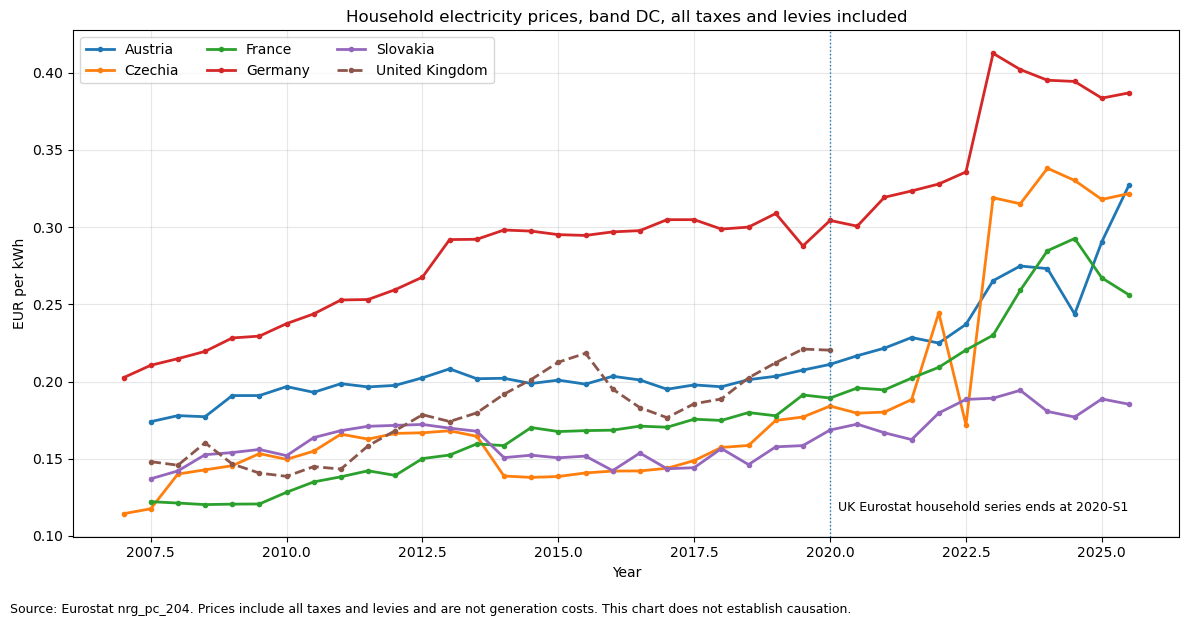

In [18]:
# This is for analysis inside the notebook, not the final portfolio export.

plt.figure(figsize=(12, 6))

for country in COUNTRIES:
    # Select rows for one country.
    country_data = household[household["geo"] == country]

    # Skip if no rows exist.
    if country_data.empty:
        continue

    # The UK line is dashed because its Eurostat series ends at 2020-S1.
    line_style = "--" if country == "United Kingdom" else "-"

    plt.plot(
        country_data["year_fraction"],
        country_data["OBS_VALUE"],
        marker="o",
        linewidth=2,
        markersize=3,
        linestyle=line_style,
        label=country,
    )

# Mark the UK cutoff point.
plt.axvline(2020, linestyle=":", linewidth=1)

plt.text(
    2020.15,
    household["OBS_VALUE"].min(),
    "UK Eurostat household series ends at 2020-S1",
    fontsize=9,
    va="bottom",
)

# Titles and labels.
plt.title("Household electricity prices, band DC, all taxes and levies included")
plt.xlabel("Year")
plt.ylabel("EUR per kWh")

# Legend and grid.
plt.legend(ncol=3)
plt.grid(True, alpha=0.3)

# Caveat.
plt.figtext(
    0.01,
    -0.03,
    "Source: Eurostat nrg_pc_204. Prices include all taxes and levies and are not generation costs. This chart does not establish causation.",
    ha="left",
    fontsize=9,
)

plt.tight_layout()
plt.show()


## First observations

The household price chart shows that prices rose across several selected countries after 2021-2022, but the size and timing of the rise differ by country.

Germany is the highest-price country for most of the series and reaches the highest observed value in this dataset. Austria rises strongly after 2022, which is useful for the project because it shows that a non-nuclear system can still face high household electricity prices. Czechia also shows a sharp post-2022 rise, while France rises more gradually and remains below Germany by the end of the period. Slovakia stays lower than the other full-coverage countries in the 2025-S2 comparison.

The United Kingdom cannot be compared after 2020-S1 using this Eurostat household file because its series stops there.

This also confirms why it was worth extending the analysis beyond 2020 where the data allows it. The post-2021 and post-2022 period is where the household price story becomes much clearer, especially for Austria, Germany and Czechia.

## Interpretation limits

This notebook compares household consumer prices, not generation costs. These prices include taxes, levies, network charges and retail margins, so they need to be interpreted alongside generation mix, market design and policy context rather than treated as a direct measure of nuclear, hydro, gas or renewables.

In [20]:
# Get the latest available price row for each country.
#  (the UK latest data is not recorded past 2020-S1)

latest_by_country = (
    household
    .sort_values(["geo", "year_fraction"])
    .groupby("geo")
    .tail(1)
    [["geo", "TIME_PERIOD", "OBS_VALUE"]]
    .rename(
        columns={
            "geo": "country",
            "TIME_PERIOD": "latest_period",
            "OBS_VALUE": "latest_price_eur_kwh",
        }
    )
    .sort_values("latest_price_eur_kwh", ascending=False)
    .reset_index(drop=True)
)

latest_by_country

,country,latest_period,latest_price_eur_kwh
0,Germany,2025-S2,0.3869
1,Austria,2025-S2,0.3272
2,Czechia,2025-S2,0.3217
3,France,2025-S2,0.2561
4,United Kingdom,2020-S1,0.2203
5,Slovakia,2025-S2,0.1853


In [22]:
snapshot_2025_s2 = (
    household[
        (household["TIME_PERIOD"] == "2025-S2")
        & (household["geo"] != "United Kingdom")
    ]
    [["geo", "TIME_PERIOD", "OBS_VALUE"]]
    .rename(
        columns={
            "geo": "country",
            "TIME_PERIOD": "period",
            "OBS_VALUE": "price_eur_kwh",
        }
    )
    .sort_values("price_eur_kwh", ascending=False)
    .reset_index(drop=True)
)

snapshot_2025_s2

,country,period,price_eur_kwh
0,Germany,2025-S2,0.3869
1,Austria,2025-S2,0.3272
2,Czechia,2025-S2,0.3217
3,France,2025-S2,0.2561
4,Slovakia,2025-S2,0.1853


In [24]:
from pathlib import Path

# ALWAYS Make sure PROJECT_ROOT points to the repo root!
processed_dir = PROJECT_ROOT / "data" / "processed"
processed_dir.mkdir(parents=True, exist_ok=True)

household_export = household[
    [
        "geo",
        "TIME_PERIOD",
        "year_fraction",
        "OBS_VALUE",
        "siec",
        "nrg_cons",
        "tax",
        "currency",
        "unit",
    ]
].rename(
    columns={
        "geo": "country",
        "TIME_PERIOD": "period",
        "OBS_VALUE": "price_eur_kwh",
    }
)

household_export_path = processed_dir / "household_price_band_dc_all_taxes.csv"
snapshot_export_path = processed_dir / "household_price_2025_s2_snapshot.csv"

household_export.to_csv(household_export_path, index=False)
snapshot_2025_s2.to_csv(snapshot_export_path, index=False)

print("Exported:")
print(household_export_path)
print(snapshot_export_path)

print("\nRows exported:")
print("household trend:", len(household_export))
print("2025-S2 snapshot:", len(snapshot_2025_s2))

Exported:
C:\Users\Tristan\Projects\nuclear-prices-carbon-europe\data\processed\household_price_band_dc_all_taxes.csv
C:\Users\Tristan\Projects\nuclear-prices-carbon-europe\data\processed\household_price_2025_s2_snapshot.csv

Rows exported:
household trend: 213
2025-S2 snapshot: 5
